# Web Scraping және Sentiment Analysis (Өзіндік жұмыс)

## 1. Кіріспе (Markdown)

**Тақырыбы:** Web Scraping және Мәтіндік деректерге Сентимент талдау жасау

**Мақсаты:**
Бұл жұмыста сіз дайын датасетті қолданбайсыз. Сіз деректерді интернеттен өз бетіңізше жинап, оны тазалап, анализ жасайсыз.

**Тапсырмалар:**

1. **Web Scraping:** `BeautifulSoup` кітапханасы арқылы `http://quotes.toscrape.com` сайтынан әйгілі тұлғалардың дәйексөздерін (цитаталарын) жинау.
2. **Data Processing:** Жиналған деректерден `Pandas DataFrame` құру.
3. **Sentiment Analysis:** `TextBlob` кітапханасы арқылы әр дәйексөздің "көңіл-күйін" (позитивті, негативті немесе бейтарап) анықтау.
4. **Визуализация:** Нәтижелерді график түрінде көрсету.

**Ескерту:** `# TODO` деп жазылған жерлерге өз кодыңызды жазуыңыз керек.

## 2. Қажетті кітапханалар (Code)

Алдымен қажетті кітапханаларды орнатып, импорттаймыз.

In [3]:
# Қажетті кітапханаларды импорттау
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# Визуализация стилін баптау
sns.set(style="whitegrid")

## 3. Web Scraping: Деректерді жинау (Code)

Біз  `http://quotes.toscrape.com` сайтынан ақпарат аламыз. Бұл сайт скрапинг үйренушілерге арналған, сондықтан бұғатталудан қорықпаймыз.

**Тапсырма:** Сайтқа сұраныс жіберіп, HTML кодын алып, `div` тегтеріндегі `quote` класы бар элементтерді табу керек.

In [4]:
# 1. Сайттың URL мекенжайы
url = "http://quotes.toscrape.com"

# 2. Сайтқа GET сұранысын жіберу
# TODO: requests кітапханасы арқылы URL-ге сұраныс жіберіңіз
response = requests.get(url)

# 3. Сұраныс сәтті өткенін тексеру (Status code 200 болуы керек)
if response.status_code == 200:
    print("Сайтпен байланыс орнатылды!")

    # 4. HTML мазмұнын BeautifulSoup арқылы парсинг жасау
    # TODO: response.text мәнін 'html.parser' арқылы оқыңыз
    soup = BeautifulSoup(response.text, 'html.parser')

    # 5. Барлық дәйексөздерді (цитаталарды) табу
    # Сайтта дәйексөздер <div class="quote"> ішінде орналасқан
    # TODO: soup.find_all функциясын қолданып, барлық 'div' элементтерін табыңыз (class_='quote')
    quotes_html = soup.find_all('div', class_='quote')

    print(f"Табылған дәйексөздер саны: {len(quotes_html)}")
else:
    print("Қате! Сайт қолжетімсіз.")

Сайтпен байланыс орнатылды!
Табылған дәйексөздер саны: 10



## 4. Деректерді өңдеу және DataFrame құру (Code)

Енді табылған HTML блоктарының ішінен нақты мәтінді (text) және авторын (author) бөліп алуымыз керек.

In [6]:
# Бос тізім құрамыз
data = []

# Әрбір HTML блогын аралап шығамыз
for quote in quotes_html:
    # 1. Дәйексөз мәтінін алу (<span class="text"> ішінде)
    # TODO: .find() қолданып, 'span' тегін және 'text' класын табыңыз. Сосын .text қасиетін алыңыз.
    text_content = quote.find('span', class_='text').text

    # 2. Автордың атын алу (<small class="author"> ішінде)
    # TODO: .find() қолданып, 'small' тегін және 'author' класын табыңыз. Сосын .text қасиетін алыңыз.
    author_name = quote.find('small', class_='author').text

    # Тізімге сөздік (dictionary) ретінде қосу
    data.append({
        'author': author_name,
        'quote': text_content
    })

# Деректерден DataFrame жасау
# TODO: pd.DataFrame функциясына data тізімін беріңіз
df = pd.DataFrame(data)

# Алғашқы 5 жолды көрсету
print("Жиналған деректер:")
display(df.head())

Жиналған деректер:


,author,quote
0,Albert Einstein,“The world as we have created it is a process ...
1,J.K. Rowling,"“It is our choices, Harry, that show what we t..."
2,Albert Einstein,“There are only two ways to live your life. On...
3,Jane Austen,"“The person, be it gentleman or lady, who has ..."
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and..."




## 5. Sentiment Analysis (Сентимент талдау) (Code)

Біз `TextBlob` кітапханасын қолданамыз. Ол мәтінге **Polarity (Полярлық)** деген баға береді:

* **-1** : Өте негативті
* **0** : Бейтарап
* **+1** : Өте позитивті

In [7]:
# Сентиментті анықтайтын функция
def get_sentiment(text):
    # TODO: TextBlob объектісін құрыңыз (blob = TextBlob(text))
    blob = TextBlob(text)

    # TODO: blob.sentiment.polarity мәнін қайтарыңыз (return ...)
    return blob.sentiment.polarity 

# Функцияны DataFrame-ге қолдану
# TODO: 'quote' бағанасына apply функциясы арқылы get_sentiment функциясын қолданыңыз
df['polarity'] = df['quote'].apply(get_sentiment)

# Сентимент категориясын анықтау (Positive, Negative, Neutral)
def categorize_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Категория бағанасын құру
df['sentiment_category'] = df['polarity'].apply(categorize_sentiment)

print("Сентимент талдауы бар деректер:")
display(df.head())

Сентимент талдауы бар деректер:


,author,quote,polarity,sentiment_category
0,Albert Einstein,“The world as we have created it is a process ...,0.000000,Neutral
1,J.K. Rowling,"“It is our choices, Harry, that show what we t...",0.300000,Positive
2,Albert Einstein,“There are only two ways to live your life. On...,0.003788,Positive
3,Jane Austen,"“The person, be it gentleman or lady, who has ...",-0.050000,Negative
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and...",-0.277778,Negative




## 6. Нәтижелерді визуализациялау (Code)

Соңғы қадам – жиналған деректердегі позитивті және негативті ойлардың үлесін көру.

C:\Users\jekim\AppData\Local\Temp\ipykernel_13492\892416984.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=df, palette='viridis')


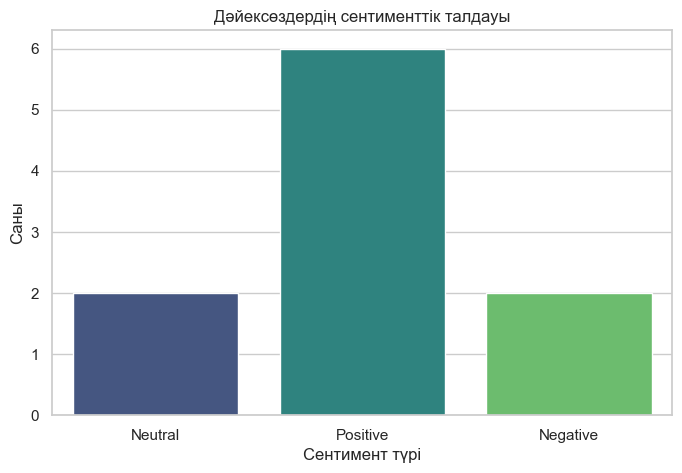

Ең позитивті дәйексөз:
“A woman is like a tea bag; you never know how strong it is until it's in hot water.”


In [8]:
# 1. Сентименттердің санын санау
sentiment_counts = df['sentiment_category'].value_counts()

# 2. График салу
plt.figure(figsize=(8, 5))

# TODO: sns.barplot немесе sns.countplot қолданып, 'sentiment_category' бағанасын визуализациялаңыз
# data параметріне df-ті беріңіз
# TODO
sns.countplot(x='sentiment_category', data=df, palette='viridis')

plt.title('Дәйексөздердің сентименттік талдауы')
plt.xlabel('Сентимент түрі')
plt.ylabel('Саны')
plt.show()

# Ең позитивті дәйексөзді шығару
print("Ең позитивті дәйексөз:")
# TODO: df деректерін сұрыптап (sort_values), ең жоғарғы polarity мәні бар жолды шығарыңыз
most_positive = df.sort_values(by='polarity', ascending=False)
print(most_positive['quote'].values[0])


## 7. Қорытынды сұрақтар (Markdown)

**Студенттің жауабы:**

1. Web Scraping жасау кезінде қандай қиындықтар туындауы мүмкін (мысалы, `status_code 403`)?
2. `TextBlob` кітапханасы сентиментті қалай анықтайды (ережеге негізделген бе әлде ML моделі ме)?
3. Егер сайтта "Келесі бет" (Next Page) батырмасы болса, барлық беттерді қалай жинауға болады? (Логикасын жазыңыз).


**Тапсырманы орындап болған соң, .ipynb файлын жүйеге жүктеңіз.**